<a href="https://colab.research.google.com/github/Vyankatesh-ops/Advanced-Machine-Learning/blob/main/Experiment_2_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_openml
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns


mnist = fetch_openml('mnist_784')
x, y = mnist['data'], mnist['target']


x = np.array(x)
y = np.array(y)


y = y.astype('int')


x.shape

(70000, 784)

In [2]:
y.shape

(70000,)

In [3]:
x_train, x_test = x[:60000], x[60000:70000]
y_train, y_test = y[:60000], y[60000:70000]


x_train.shape

(60000, 784)

In [4]:
y_train.shape

(60000,)

In [5]:
y_test.shape

(10000,)

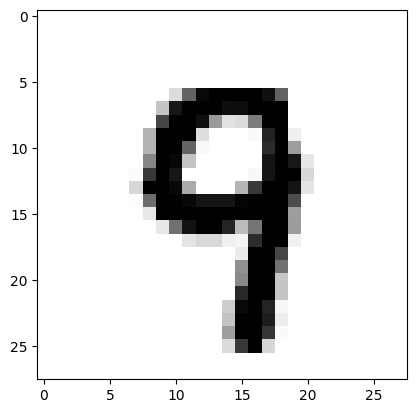

In [6]:
some_image = x[520]
some_image = some_image.reshape(28,28)
plt.imshow(some_image, cmap=matplotlib.cm.binary,interpolation='nearest')

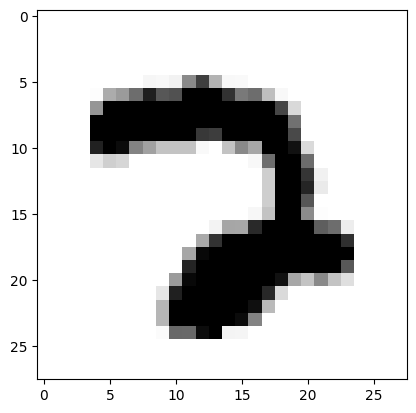

In [7]:
some_image = x[120]
some_image = some_image.reshape(28,28)
plt.imshow(some_image, cmap=matplotlib.cm.binary,interpolation='nearest')

In [8]:
def bagging():

  indexes = np.random.randint(0, len(x_train), len(x_train))
  bag = x_train[indexes]
  target = y_train[indexes]
  return (bag,target)


In [9]:
bag1 = bagging()
print(bag1[0].shape,'\n', bag1[1].shape)

(60000, 784) 
 (60000,)


In [10]:
dtc1 = DecisionTreeClassifier()        # training bag 1
dtc1.fit(bag1[0], bag1[1])

DecisionTreeClassifier()

In [11]:
bag2 = bagging()
print(bag2[0].shape,'\n', bag2[1].shape)

(60000, 784) 
 (60000,)


In [12]:
dtc2 = DecisionTreeClassifier()        # training bag 2
dtc2.fit(bag2[0], bag2[1])


DecisionTreeClassifier()

In [13]:

bag3 = bagging()
print(bag3[0].shape,'\n', bag3[1].shape)

(60000, 784) 
 (60000,)


In [14]:
dtc3 = DecisionTreeClassifier()        # training bag 3
dtc3.fit(bag3[0], bag3[1])


DecisionTreeClassifier()

In [15]:
pred_1 = dtc1.predict(x_test)
pred_2 = dtc2.predict(x_test)
pred_3 = dtc3.predict(x_test)

In [16]:
y_pred = []

for i in range(len(x_test)):

  node = [pred_1[i], pred_2[i], pred_3[i]]
  majority_vote = max( node , key = node.count)
  y_pred.append(majority_vote)

y_pred = np.array(y_pred)





y_pred.shape

(10000,)

In [17]:
y[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])

In [18]:
print(accuracy_score( y_test, y_pred))    # accuracy

0.8992


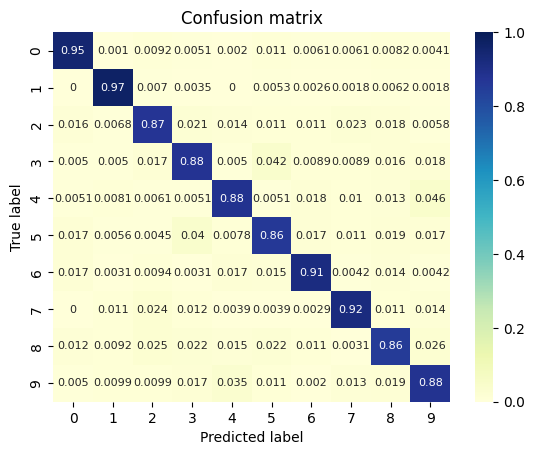

In [19]:
def plot_confusion_matrix(cm, classes=None, title='Confusion matrix'):
    """Plots a confusion matrix."""
    if classes is not None:
        sns.heatmap(cm, cmap="YlGnBu", xticklabels=classes, yticklabels=classes, vmin=0., vmax=1., annot=True, annot_kws={'size': 8})
    else:
        sns.heatmap(cm, vmin=0., vmax=1.)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


from sklearn.metrics import r2_score, explained_variance_score, confusion_matrix, accuracy_score, classification_report
cm3 = confusion_matrix(y_test, y_pred)
cm_norm3 = cm3 / cm3.sum(axis=1).reshape(-1,1)

plot_confusion_matrix(cm_norm3, classes = [0,1,2,3,4,5,6,7,8,9], title='Confusion matrix')

In [ ]:
#Gradient boosting from this line

In [21]:
from sklearn.datasets import fetch_openml
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, explained_variance_score, confusion_matrix, accuracy_score, classification_report, mean_absolute_error
import seaborn as sns

In [22]:
mnist = fetch_openml('mnist_784')

In [23]:
x, y = mnist['data'], mnist['target']


x = np.array(x)
y = np.array(y)


x.shape


(70000, 784)

In [24]:
y = y.astype('int')


x_train, x_test = x[:60000], x[60000:70000]
y_train, y_test = y[:60000], y[60000:70000]


x_train.shape

(60000, 784)

In [25]:
x_test.shape

(10000, 784)

In [26]:
y_train.shape

(60000,)

In [27]:
y_test.shape

(10000,)

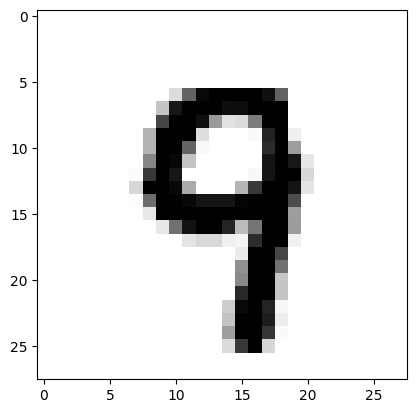

In [28]:
some_image = x[520]
some_image = some_image.reshape(28,28)
plt.imshow(some_image, cmap=matplotlib.cm.binary,interpolation='nearest')

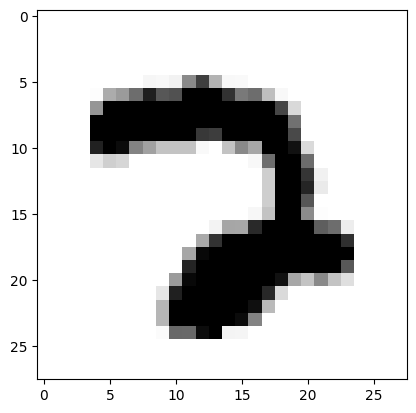

In [29]:
some_image = x[120]
some_image = some_image.reshape(28,28)
plt.imshow(some_image, cmap=matplotlib.cm.binary,interpolation='nearest')

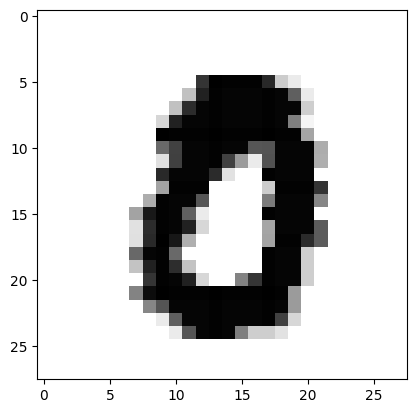

In [30]:
some_image = x[69]
some_image = some_image.reshape(28,28)
plt.imshow(some_image, cmap=matplotlib.cm.binary,interpolation='nearest')

In [31]:
lr = 0.1   #learning rate


dt = DecisionTreeRegressor(max_depth = 1)
dt.fit(x_train,y_train)


DecisionTreeRegressor(max_depth=1)

In [32]:
y_pred = dt.predict(x_test)


y_pred[:10]

array([5.36713732, 2.6254691 , 2.6254691 , 2.6254691 , 5.36713732,
       2.6254691 , 5.36713732, 5.36713732, 2.6254691 , 5.36713732])

In [33]:

mae = mean_absolute_error(y_test,  y_pred)
mae


2.2267110373114707

In [34]:
score = r2_score(y_test, y_pred)
score

0.22100481734722877

In [35]:
y_pred = np.round(y_pred)


print(accuracy_score( y_test, y_pred))    # accuracy

0.0716


In [36]:
y_it1 = dt.predict(x_train)
y_it1 = np.round(y_it1)


y_train1 = y_train - y_it1


dt1 = DecisionTreeRegressor(max_depth = 1)
dt1.fit(x_train,  y_train1)



DecisionTreeRegressor(max_depth=1)

In [37]:
y_pred1 = dt1.predict(x_test)
y_pred1 = np.round(y_pred1)
print(accuracy_score( y_test, y_pred + y_pred1 ))    # accuracy


0.1238


In [38]:
y_it2 = dt1.predict(x_train)
y_it2 = np.round(y_it2)


y_train2 = y_train1 - y_it2


dt2 = DecisionTreeRegressor(max_depth = 1)
dt2.fit(x_train,  y_train2)


DecisionTreeRegressor(max_depth=1)

In [39]:
y_pred2 = dt2.predict(x_test)
y_pred2 = np.round(y_pred2)
print(accuracy_score( y_test, y_pred + y_pred1 + y_pred2 ))    # accuracy


0.1371


In [40]:
y_it3 = dt2.predict(x_train)
y_it3 = np.round(y_it3)


y_train3 =  y_train2 - y_it3


dt3 = DecisionTreeRegressor(max_depth = 1)
dt3.fit( x_train,  y_train3 )


DecisionTreeRegressor(max_depth=1)

In [41]:
y_pred3 = dt3.predict(x_test)
y_pred3 = np.round(y_pred3)
print(accuracy_score( y_test, y_pred + y_pred1 + y_pred2 + y_pred3 ))    # accuracy

0.1934


In [42]:

y_it4 = dt3.predict(x_train)
y_it4 = np.round(y_it4)


y_train4 =  y_train3 - y_it4


dt4 = DecisionTreeRegressor(max_depth = 1)
dt4.fit( x_train,  y_train4 )


DecisionTreeRegressor(max_depth=1)

In [43]:
y_pred4 = dt4.predict(x_test)
y_pred4 = np.round(y_pred4)
print(accuracy_score( y_test, y_pred + y_pred1 + y_pred2 + y_pred3 + y_pred4))    # accuracy

0.1447


In [44]:
y_it5 = dt4.predict(x_train)
y_it5 = np.round(y_it5)


y_train5 =  y_train4 - y_it5


dt5 = DecisionTreeRegressor(max_depth = 1)
dt5.fit( x_train,  y_train4 )


DecisionTreeRegressor(max_depth=1)

In [45]:
y_pred5 = dt5.predict(x_test)
y_pred5 = np.round(y_pred5)
print(accuracy_score( y_test, y_pred + y_pred1 + y_pred2 + y_pred3 + y_pred4 + y_pred5 ))    # accuracy


0.1544
